# Cluster maps

In [1]:
import fitsio
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, setdiff
import pyccl as ccl
from ulid import ULID

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *
from utile_fitsFile import *

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Opening file

In [3]:
output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
outputfile = output_path + sufix + '.fits'

data = fitsio.FITS(outputfile)
data


  file: Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY
  3      BINARY_TBL      FIT_MINUIT

In [4]:
# data.close()
# original = outputfile
# clear = output_path + 'new.fits'
# remove_HDU(original, clear, 4)

## Study of numpy method

It is the chatGPT version, using matrix invertion and numpy tools.

In [5]:
dfNumpy = Table(data['FIT_NUMPY'].read()).to_pandas()
dfNumpy

,Map_ID,A,Dx,Dy,Dz
0,01KNRHFD1J62D5NP0SRDEC0FCG,0.000687,-0.000474,0.000267,0.000419
1,01KNRHFD297TAFZ5Q68YCPK2VM,0.000387,0.000055,0.000302,-0.000236
2,01KNRHFD2XDEPBV818WS1J7RMY,0.000453,-0.000048,-0.000256,0.000370
3,01KNRHFD3RZE96226Y8AYCBX44,0.000285,-0.000273,-0.000040,-0.000074
4,01KNRHFD45ET7XHNHGDBBZBR7X,0.000539,0.000383,0.000317,0.000207
...,...,...,...,...,...
9995,01KNRNDH3XQBH45KSDSC0R5F6D,0.000975,-0.000548,-0.000262,0.000763
9996,01KNRNDH429YRKDE22FVY9116E,0.000413,0.000303,0.000272,0.000068
9997,01KNRNDH48V6ETZTZTZ9ZTNAGB,0.000845,0.000391,-0.000097,0.000743
9998,01KNRNDH4EG5WY64YG8PM658JB,0.000668,-0.000083,0.000518,0.000413


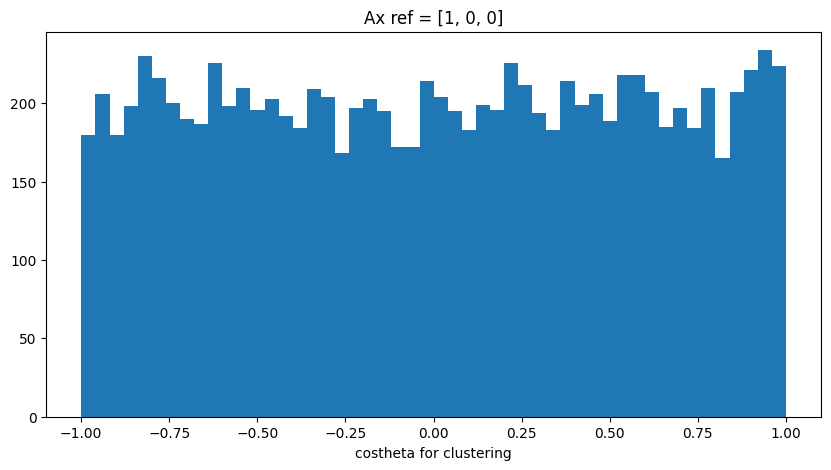

In [6]:
def get_costheta_cartesian(df, axref=[1, 0, 0]):
    data = df.copy()
    axref = np.array(axref)
    axref = axref/np.linalg.norm(axref)
    dip = np.array(data[['Dx', 'Dy', 'Dz']])
    return np.dot(dip, axref)/data['A']

axref = [1, 0, 0]
dfNumpy['costheta'] = dfNumpy.apply(get_costheta_cartesian, axis=1, args=(axref,))
col = 'costheta'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(dfNumpy[col], xlabel=f"{col} for clustering", bins=50, figax=(fig, ax), title=f"Ax ref = {axref}");

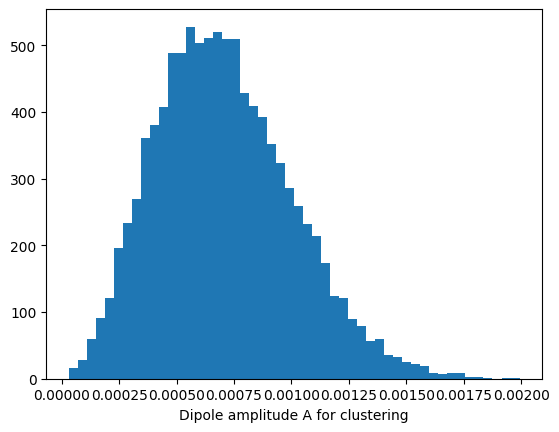

In [7]:
col = 'A'
fig, ax = plt.subplots()
get_hist(dfNumpy[col], xlabel=f"Dipole amplitude {col} for clustering", bins=50, figax=(fig, ax));

In [8]:
dfNumpy.describe()

,A,Dx,Dy,Dz,costheta
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000
mean,0.000707,0.000002,-7.693099e-07,-4.658319e-08,0.007257
std,0.000297,0.000446,4.402594e-04,4.428252e-04,0.581251
min,0.000030,-0.001693,-1.547497e-03,-1.713045e-03,-0.999241
25%,0.000489,-0.000304,-2.955812e-04,-3.017372e-04,-0.503932
50%,0.000683,0.000008,-3.325031e-06,-2.818449e-07,0.015391
75%,0.000899,0.000301,3.018153e-04,2.981659e-04,0.514121
max,0.001993,0.001584,1.815689e-03,1.728033e-03,0.999735


In [9]:
def get_lb(df):
    data = df.copy()
    xyz = np.array(data[['Dx', 'Dy', 'Dz']])
    dip = SkyCoord(*xyz, frame='galactic', representation_type='cartesian', unit=u.pc)
    return dip.spherical.lon.value, dip.spherical.lat.value

dfNumpy[['l', 'd']] = dfNumpy.apply(get_lb, axis=1, result_type='expand')
dfNumpy

,Map_ID,A,Dx,Dy,Dz,costheta,l,d
0,01KNRHFD1J62D5NP0SRDEC0FCG,0.000687,-0.000474,0.000267,0.000419,-0.690668,150.593228,37.550390
1,01KNRHFD297TAFZ5Q68YCPK2VM,0.000387,0.000055,0.000302,-0.000236,0.141716,79.703455,-37.547447
2,01KNRHFD2XDEPBV818WS1J7RMY,0.000453,-0.000048,-0.000256,0.000370,-0.105558,259.424785,54.888827
3,01KNRHFD3RZE96226Y8AYCBX44,0.000285,-0.000273,-0.000040,-0.000074,-0.955430,188.403990,-15.027610
4,01KNRHFD45ET7XHNHGDBBZBR7X,0.000539,0.000383,0.000317,0.000207,0.711229,39.618266,22.586268
...,...,...,...,...,...,...,...,...
9995,01KNRNDH3XQBH45KSDSC0R5F6D,0.000975,-0.000548,-0.000262,0.000763,-0.561603,205.566075,51.496777
9996,01KNRNDH429YRKDE22FVY9116E,0.000413,0.000303,0.000272,0.000068,0.734312,41.883875,9.489432
9997,01KNRNDH48V6ETZTZTZ9ZTNAGB,0.000845,0.000391,-0.000097,0.000743,0.462524,346.082889,61.542175
9998,01KNRNDH4EG5WY64YG8PM658JB,0.000668,-0.000083,0.000518,0.000413,-0.124974,99.152883,38.218712


## Study of minuit method

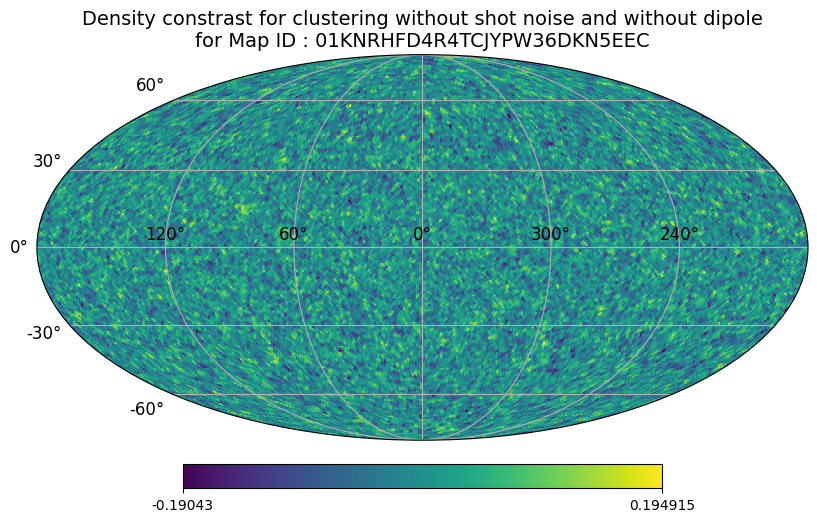

In [10]:
mapID = get_ID_not_in(data, HDU_ref ='FIT_MINUIT', HDU_target='MAPS')[0] #first map not fitted yet by minuit
idxID = get_indexID(data, mapID)
map = data['MAPS']['Map'][idxID][0]
title=f"Density constrast for clustering without shot noise and without dipole\nfor Map ID : {mapID}"
hp.projview(map, title=title, graticule=True, graticule_labels=True);

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1856 (χ²/ndof = 0.0)       │              Nfcn = 415              │
│ EDM = 1.34e-06 (Goal: 0.0002)    │            time = 4.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │    0.0    │    0.1    │            │            │    0    │         │  yes  │
│ 1 │ A    │  0.04e-3  │  2.14e-3  │  -0.04e-3  │  0.62e-3   │    0    │    1    │       │
│ 2 │ l    │  0.15e3   │  0.28e3   │  -0.15e3   │   0.21e3   │    0    │   360   │       │
│ 3 │ b    │    -20    │    140    │    -70     │    110     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.04e-3  │  0.62e-3  │  -0.15e3  │  0.21e3   │    -70    │    110    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────────────┐
│   │           M           A           l           b │
├───┼─────────────────────────────────────────────────┤
│ M │           0           0           0           0 │
│ A │           0    3.81e-07 -32.1390e-3  10.6508e-3 │
│ l │           0 -32.1390e-3     6.1e+05       0.1e6 │
│ b │           0  10.6508e-3       0.1e6    5.27e+05 │
└───┴─────────────────────────────────────────────────┘

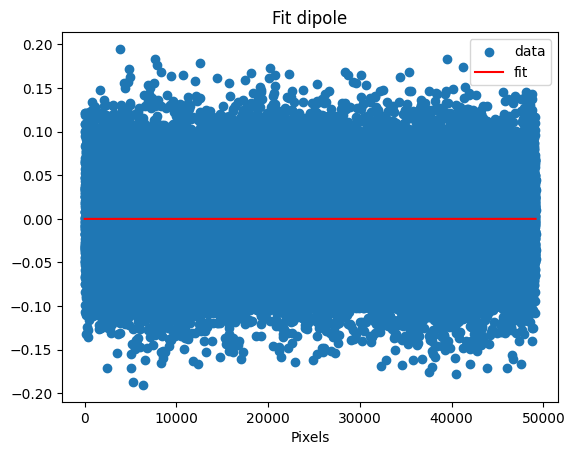

In [11]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=False, frame='icrs')
init =  (0, 3, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), fixed="M")
dic_param = get_dicParam_minuit(m, mapID, add_param={'Coord': 'spherical'})
dfMinuit = dic_param.copy()
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1856 (χ²/ndof = 0.0)       │              Nfcn = 345              │
│ EDM = 8.34e-06 (Goal: 0.0002)    │            time = 3.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │    0.0    │    0.1    │            │            │    0    │         │  yes  │
│ 1 │ A    │  0.05e-3  │  2.11e-3  │  -0.05e-3  │  0.62e-3   │    0    │    1    │       │
│ 2 │ l    │  0.15e3   │  0.28e3   │  -0.15e3   │   0.21e3   │    0    │   360   │       │
│ 3 │ b    │    -20    │    120    │    -70     │    110     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.05e-3  │  0.62e-3  │  -0.15e3  │  0.21e3   │    -70    │    110    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────────────┐
│   │           M           A           l           b │
├───┼─────────────────────────────────────────────────┤
│ M │           0           0           0           0 │
│ A │           0    3.82e-07 -64.5017e-3  10.1017e-3 │
│ l │           0 -64.5017e-3    6.08e+05       0.1e6 │
│ b │           0  10.1017e-3       0.1e6     5.2e+05 │
└───┴─────────────────────────────────────────────────┘

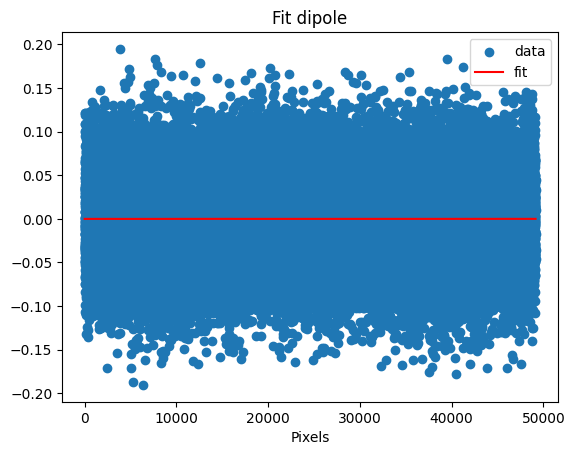

In [12]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=False, frame='icrs')
init =  (0, 3, 120, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), fixed="M")
dic_param = get_dicParam_minuit(m, mapID, add_param={'Coord': 'spherical'})
dfMinuit = pd.concat([dfMinuit, dic_param], ignore_index=True)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1856 (χ²/ndof = 0.0)       │              Nfcn = 139              │
│ EDM = 5.42e-05 (Goal: 0.0002)    │            time = 0.6 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │    0.0    │    0.1    │            │            │    0    │         │  yes  │
│ 1 │ Dx   │    -0     │  0.6e-3   │  -0.6e-3   │   0.6e-3   │   -1    │    1    │       │
│ 2 │ Dy   │     0     │  0.6e-3   │  -0.6e-3   │   0.6e-3   │   -1    │    1    │       │
│ 3 │ Dz   │    -0     │  0.6e-3   │  -0.6e-3   │   0.6e-3   │   -1    │    1    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          Dx           │          Dy           │          Dz           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.6e-3  │  0.6e-3   │  -0.6e-3  │  0.6e-3   │  -0.6e-3  │  0.6e-3   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────┬─────────────────────────────────────┐
│    │        M       Dx       Dy       Dz │
├────┼─────────────────────────────────────┤
│  M │        0        0        0        0 │
│ Dx │        0 3.61e-07 -0.02e-6 -0.01e-6 │
│ Dy │        0 -0.02e-6 3.47e-07 -0.06e-6 │
│ Dz │        0 -0.01e-6 -0.06e-6 3.26e-07 │
└────┴─────────────────────────────────────┘

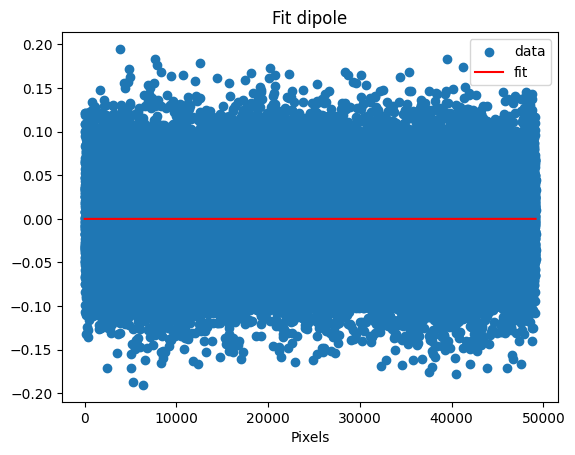

In [13]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=False, frame='cartesian')
init =  (0, 0, 0, 0)
names = ("M", "Dx", "Dy", "Dz")
m = fit_dipole_err(model, map, init, names, bounds=([0, -1, -1, -1], [np.inf, 1, 1, 1]), fixed="M")
dic_param = get_dicParam_minuit(m, mapID, add_param={'Coord': 'cartesian'})
dfMinuit = pd.concat([dfMinuit, dic_param], ignore_index=True)
m

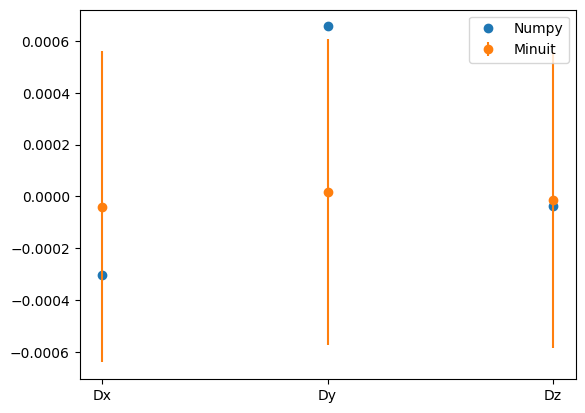

In [14]:
plt.plot(dfNumpy.set_index('Map_ID').loc[mapID][['Dx', 'Dy', 'Dz']], marker='o', linestyle='', label='Numpy')
plt.errorbar(['Dx', 'Dy', 'Dz'], dic_param.loc[0][['Dx', 'Dy', 'Dz']], yerr=dic_param.loc[0][['Dx_err', 'Dy_err', 'Dz_err']], marker='o', linestyle='', label='Minuit')
plt.legend();

In [15]:
dfMinuit

,Map_ID,M,M_init,M_err,M_fixed,M_limit_0,M_limit_1,A,A_init,A_err,...,Dy_err,Dy_fixed,Dy_limit_0,Dy_limit_1,Dz,Dz_init,Dz_err,Dz_fixed,Dz_limit_0,Dz_limit_1
0,01KNRHFD4R4TCJYPW36DKN5EEC,0.0,0.0,0.1,True,0.0,inf,0.000045,1.0,0.002137,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01KNRHFD4R4TCJYPW36DKN5EEC,0.0,0.0,0.1,True,0.0,inf,0.000045,1.0,0.002112,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01KNRHFD4R4TCJYPW36DKN5EEC,0.0,0.0,0.1,True,0.0,inf,NaN,NaN,NaN,...,0.000589,False,-1.0,1.0,-0.000013,0.0,0.000571,False,-1.0,1.0


In [16]:
data.close()
dfMinuit_filtered = get_save_fit_dfMinuit(dfMinuit, outputfile)

Saving complete.


/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/simulMap.py:306: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(False, inplace=True)
/home/victoria/Travaux_Jupyter_Ububtu/M2Stage_JohannGit/M2_Stage_Code/Simulation/simulMap.py:306: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasti

In [17]:
data = fitsio.FITS(outputfile)
Table(data['FIT_MINUIT'].read())

Map_ID,M,M_init,M_err,M_fixed,M_limit_0,M_limit_1,A,A_init,A_err,A_fixed,A_limit_0,A_limit_1,l,l_init,l_err,l_fixed,l_limit_0,l_limit_1,b,b_init,b_err,b_fixed,b_limit_0,b_limit_1,valid,Coord,Dx,Dx_init,Dx_err,Dx_fixed,Dx_limit_0,Dx_limit_1,Dy,Dy_init,Dy_err,Dy_fixed,Dy_limit_0,Dy_limit_1,Dz,Dz_init,Dz_err,Dz_fixed,Dz_limit_0,Dz_limit_1
str26,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,bool,str9,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64,float64,float64,float64,bool,float64,float64
01KNRHFD1J62D5NP0SRDEC0FCG,0.0,0.0,0.1,True,0.0,inf,6.571938794718704e-05,1.0,0.0012829626308812733,False,0.0,1.0,172.2025129415633,20.0,269.36635249397676,False,0.0,360.0,89.9883297828077,40.0,154.3772671225816,False,-90.0,90.0,True,spherical,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan
01KNRHFD1J62D5NP0SRDEC0FCG,0.0,0.0,0.1,True,0.0,inf,9.054407968689602e-05,1.0,0.0009356310207443497,False,0.0,1.0,179.0796755032638,120.0,234.17225678531386,False,0.0,360.0,46.16689258903281,40.0,109.02212464033062,False,-90.0,90.0,True,spherical,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan
01KNRHFD1J62D5NP0SRDEC0FCG,0.0,0.0,0.1,True,0.0,inf,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,True,cartesian,-6.020468248102895e-05,0.0,0.0005919651020845076,False,-1.0,1.0,1.7029782001764778e-06,0.0,0.0004822375055840672,False,-1.0,1.0,6.421841956433705e-05,0.0,0.0005854549737822537,False,-1.0,1.0
01KNRHFD297TAFZ5Q68YCPK2VM,0.0,0.0,0.1,True,0.0,inf,8.197160031699633e-06,1.0,0.006688229506890044,False,0.0,1.0,181.3298257099353,120.0,262.9126559119843,False,0.0,360.0,-77.40396786292919,40.0,165.70552583408494,False,-90.0,90.0,True,spherical,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan
01KNRHFD297TAFZ5Q68YCPK2VM,0.0,0.0,0.1,True,0.0,inf,1.682983186405954e-05,1.0,0.004347118765357861,False,0.0,1.0,223.8903866877042,20.0,268.89251888083606,False,0.0,360.0,-9.635821735513527,40.0,110.695229464154,False,-90.0,90.0,True,spherical,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan
01KNRHFD297TAFZ5Q68YCPK2VM,0.0,0.0,0.1,True,0.0,inf,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,True,cartesian,-1.2286573142766724e-05,0.0,0.000510890342123952,False,-1.0,1.0,-1.0840207930533873e-05,0.0,0.000441962896618399,False,-1.0,1.0,-3.8100722612126716e-07,0.0,0.000552294410210185,False,-1.0,1.0
01KNRHFD2XDEPBV818WS1J7RMY,0.0,0.0,0.1,True,0.0,inf,2.8412584295137378e-05,1.0,0.002975147777360052,False,0.0,1.0,0.028041438317023493,20.0,357.5689949380369,False,0.0,360.0,58.14819308197867,40.0,98.41826541592259,False,-90.0,90.0,True,spherical,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan
01KNRHFD2XDEPBV818WS1J7RMY,0.0,0.0,0.1,True,0.0,inf,3.200068844633894e-05,1.0,0.0026314365958661793,False,0.0,1.0,0.41143552965567587,120.0,357.8808795263201,False,0.0,360.0,62.458915989845615,40.0,108.40757439349522,False,-90.0,90.0,True,spherical,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan
01KNRHFD2XDEPBV818WS1J7RMY,0.0,0.0,0.1,True,0.0,inf,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,nan,nan,nan,False,nan,nan,True,cartesian,1.4824274233782905e-05,0.0,0.00048028105551291457,False,-1.0,1.0,-1.3605490205693667e-05,0.0,0.0005381447792566276,False,-1.0,1.0,2.2887805042880638e-05,0.0,0.0005291979110260616,False,-1.0,1.0
